In [2]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import Inference as inf

In [3]:
import sys
from src import dataloader

In [4]:
MIN_EXTREME_VALUE_Threshold = 22.24
Max_EXTREME_VALUE_Threshold = 54.36

### Return 10th, 50th, and 90th of keywords in training dataset

In [5]:
data_loader_training, data_loader_validate, data_loader_test = dataloader.get_dataloaders(
    batch_size = 1, 
    img_size = 16,
    in_channels = 8, 
    resmapling_status = False,
    data = 's2',
    exp_name = 'test'
    )

(13875, 36) | (8233, 36) | (12443, 36)


In [11]:
# Example keywords to extract
keywords = ['soil texture', 'pH', 'electrical conductivity', 'calcium', 'magnesium', 
            'sodium', 'exchangeable sodium percentage', 'boron', 'nitrate nitrogen', 
            'phosphate phosphorus', 'potassium', 'zinc', 'manganese', 'iron', 'copper', 'organic matter']
keywords_dict = inf.process_texts(data_loader_training, keywords)
for keyword, percentile_values in keywords_dict.items():
    print(f"{keyword}:")
    # Collect percentiles in the desired format
    formatted_percentiles = " | ".join([f"{percentile}: {value}" for percentile, value in percentile_values.items()])
    print(f"  {formatted_percentiles}")

soil texture:
  10th: 21.0 | 50th: 22.0 | 90th: 24.0
pH:
  10th: 5.8 | 50th: 7.1 | 90th: 7.8
electrical conductivity:
  10th: 0.6 | 50th: 1.09 | 90th: 7.2
calcium:
  10th: 2.1 | 50th: 3.0 | 90th: 7.9
magnesium:
  10th: 0.6 | 50th: 1.8 | 90th: 5.7
sodium:
  10th: 2.1 | 50th: 7.3 | 90th: 49.1
exchangeable sodium percentage:
  10th: 1.2 | 50th: 4.0 | 90th: 24.0
boron:
  10th: 0.1 | 50th: 0.1 | 90th: 0.2
nitrate nitrogen:
  10th: 3.0 | 50th: 3.0 | 90th: 3.0
phosphate phosphorus:
  10th: 4.0 | 50th: 4.0 | 90th: 4.0
potassium:
  10th: 27.0 | 50th: 70.0 | 90th: 194.0
zinc:
  10th: 1.2 | 50th: 3.8 | 90th: 7.7
manganese:
  10th: 2.0 | 50th: 3.7 | 90th: 12.0
iron:
  10th: 6.4 | 50th: 28.7 | 90th: 36.5
copper:
  10th: 0.6 | 50th: 1.0 | 90th: 1.4
organic matter:
  10th: 0.24 | 50th: 0.41 | 90th: 0.79


### Analysis

In [12]:
E003 = '002_s12mettext_vit_768_8_6_8_30_0001_01_64_init01'

In [4]:
Ex_003 = inf.performance(E003)
Ex_003.mape_per_yield_range(th1 = MIN_EXTREME_VALUE_Threshold, 
                            th2 = Max_EXTREME_VALUE_Threshold)

All: MAE = 3.42, MAPE = 10.60 | C1: MAE = 3.04, MAPE = 16.31 | C2: MAE = 3.19, MAPE = 9.92 | C3: MAE = 8.10, MAPE = 13.39


#### Analysis 1: increasing the amount of 

In [14]:
for keyword, percentile_values in keywords_dict.items():
    # Loop through 10th, 50th, and 90th percentiles
    for percentile, value in percentile_values.items():
        # Skip if the value is None
        if value is None:
            continue
        inf_dataloader = dataloader.sns_inference_dataloader(batch_size = 64, 
                                    exp_name = E003, 
                                    keyword = keyword, 
                                    new_avlue = value)

        inf.predict(inf_dataloader, exp_name= E003, keyword= keyword, new_value = value)

Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!
Done!


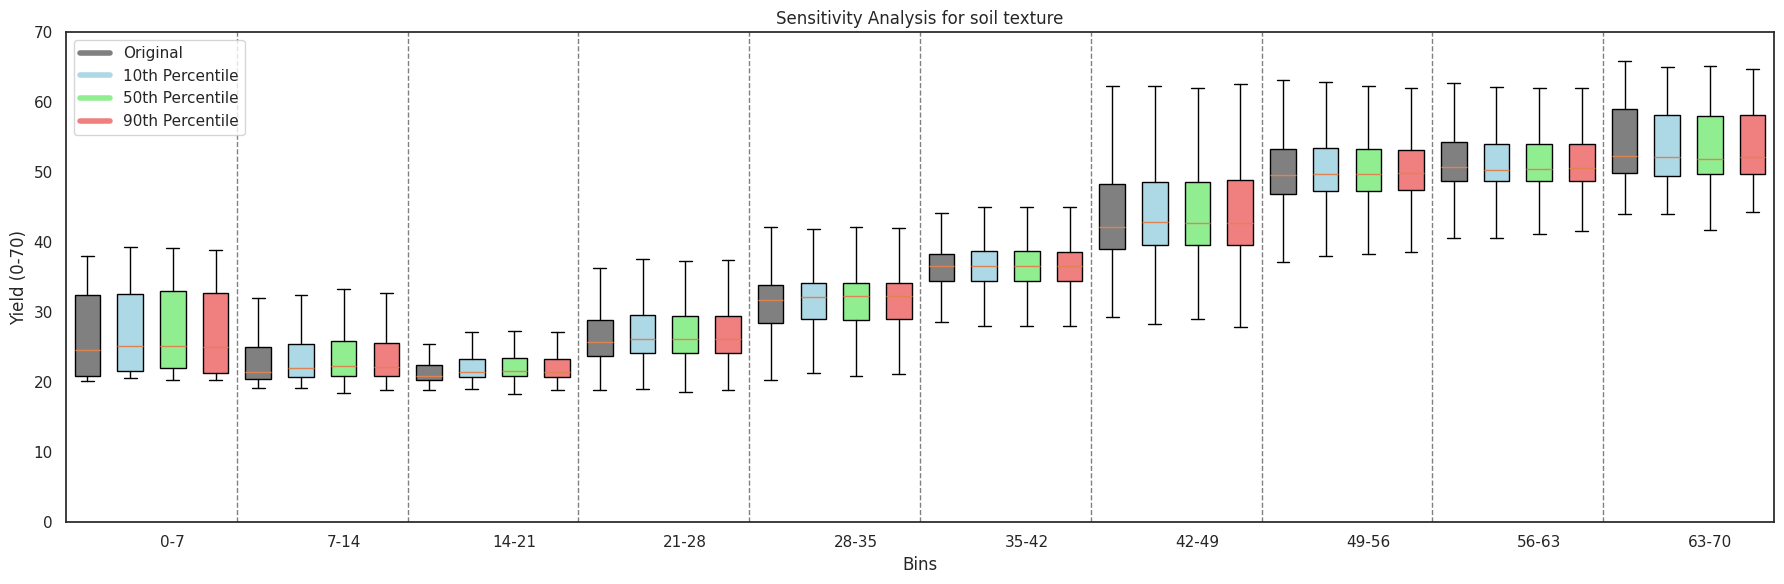

In [33]:
values = keywords_dict.get("soil texture")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "soil texture", 
                              values = values_list)

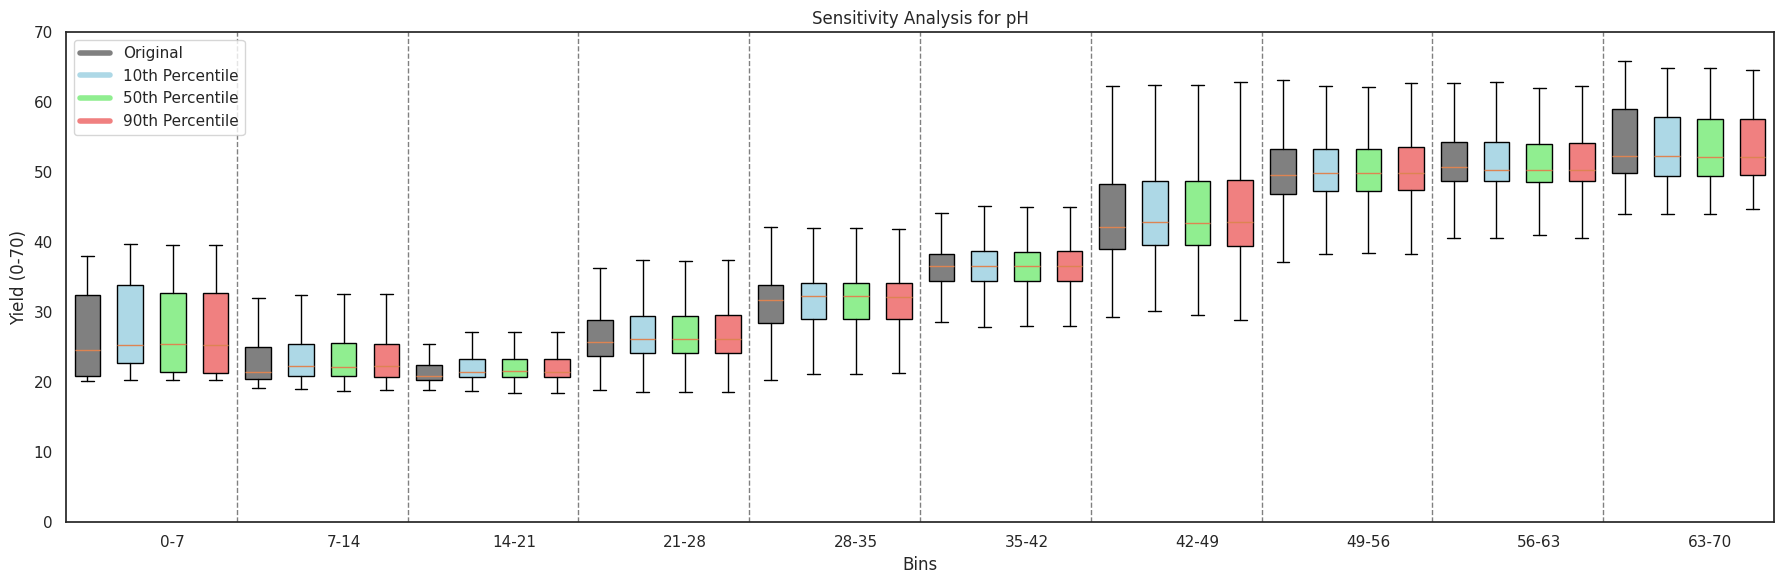

In [34]:
values = keywords_dict.get("pH")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "pH", 
                              values = values_list)

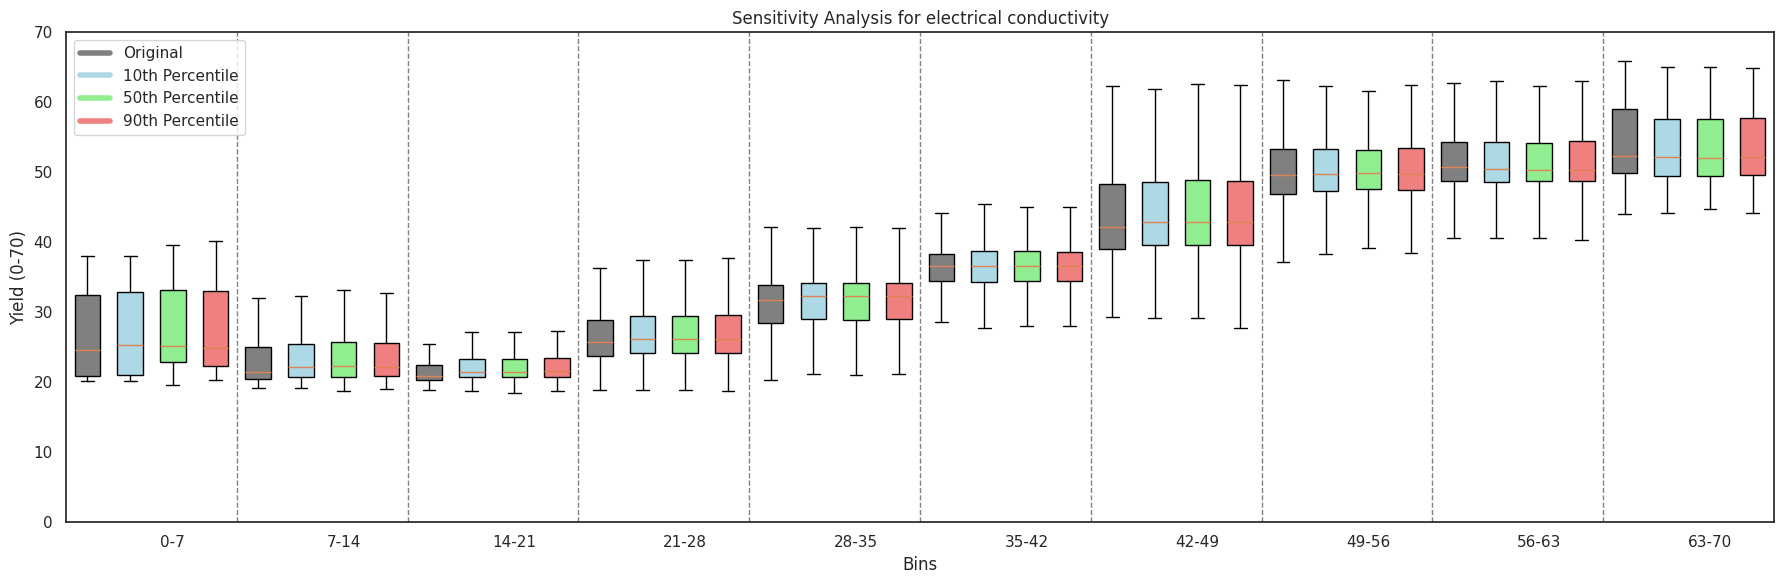

In [35]:
values = keywords_dict.get("electrical conductivity")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "electrical conductivity", 
                              values = values_list)

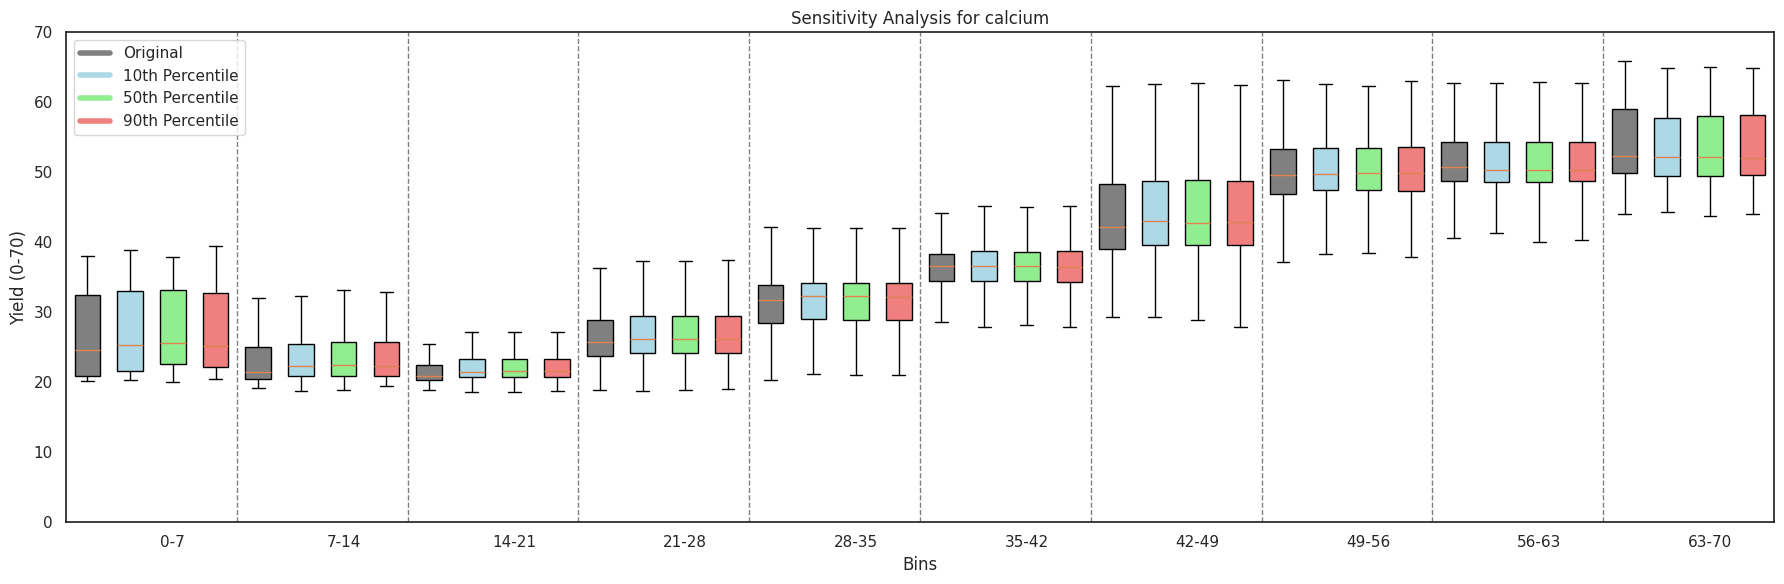

In [36]:
values = keywords_dict.get("calcium")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "calcium", 
                              values = values_list)

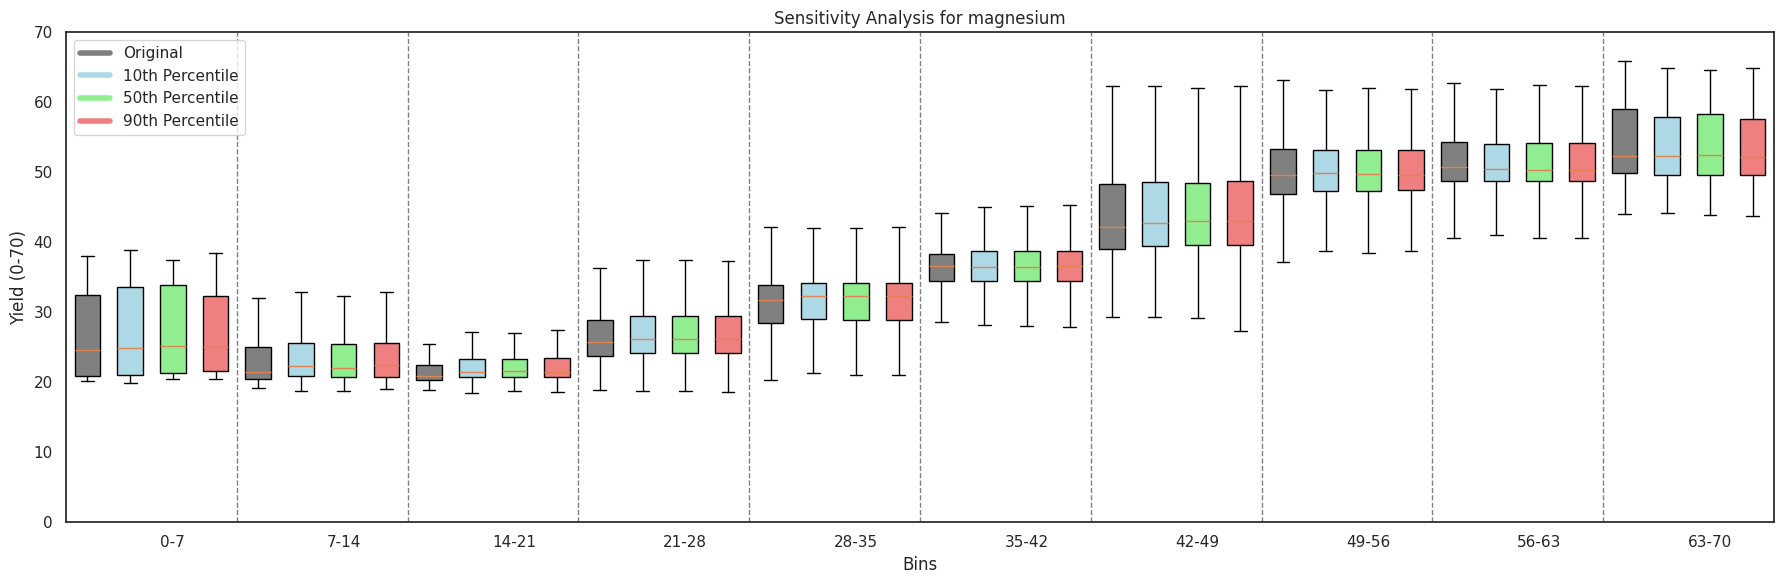

In [37]:
values = keywords_dict.get("magnesium")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "magnesium", 
                              values = values_list)

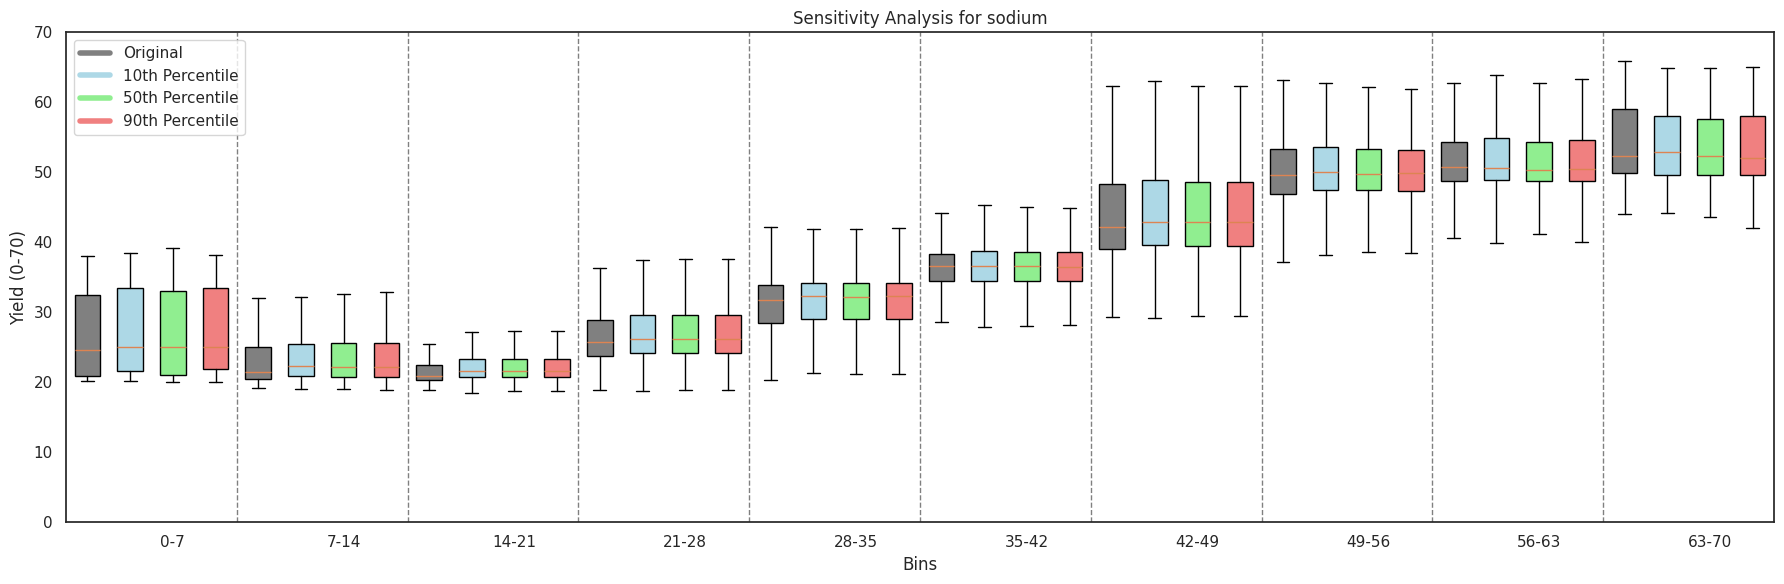

In [38]:
values = keywords_dict.get("sodium")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "sodium", 
                              values = values_list)

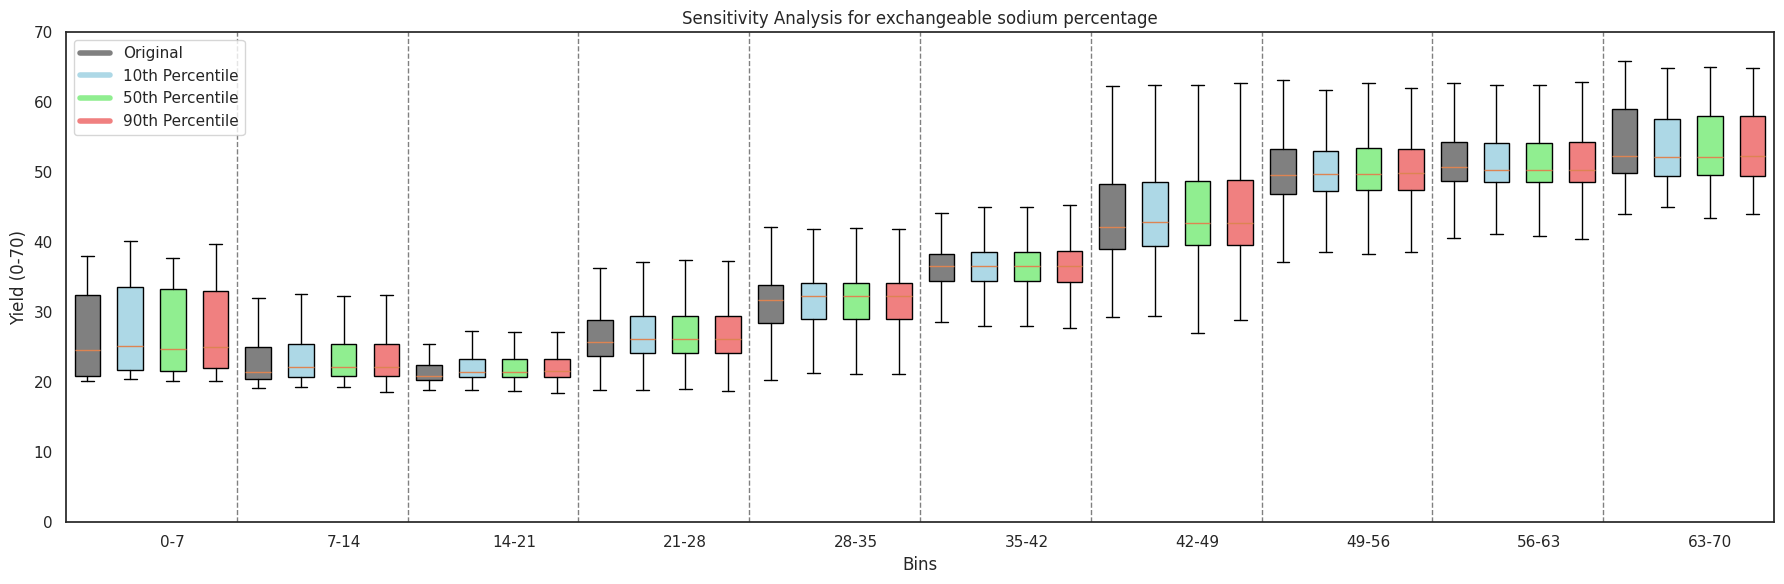

In [39]:
values = keywords_dict.get("exchangeable sodium percentage")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "exchangeable sodium percentage", 
                              values = values_list)

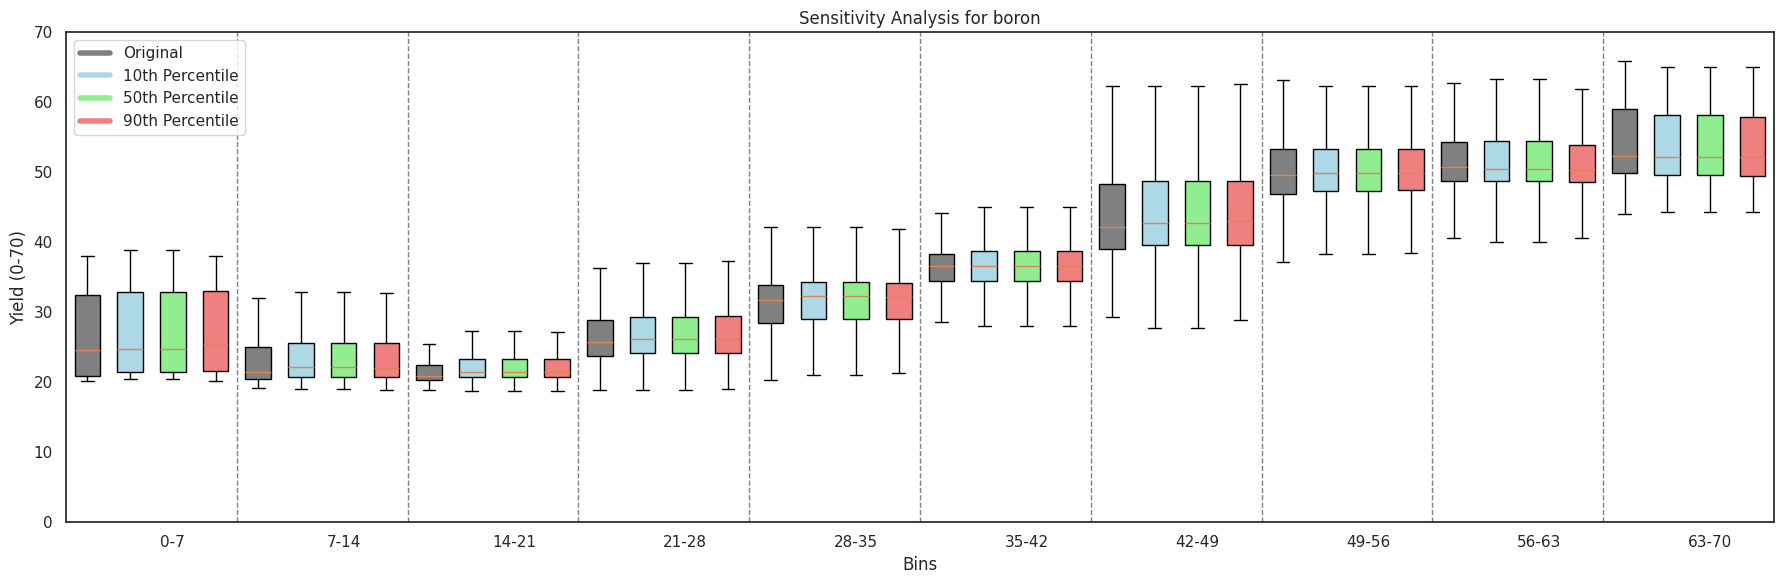

In [40]:
values = keywords_dict.get("boron")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "boron", 
                              values = values_list)

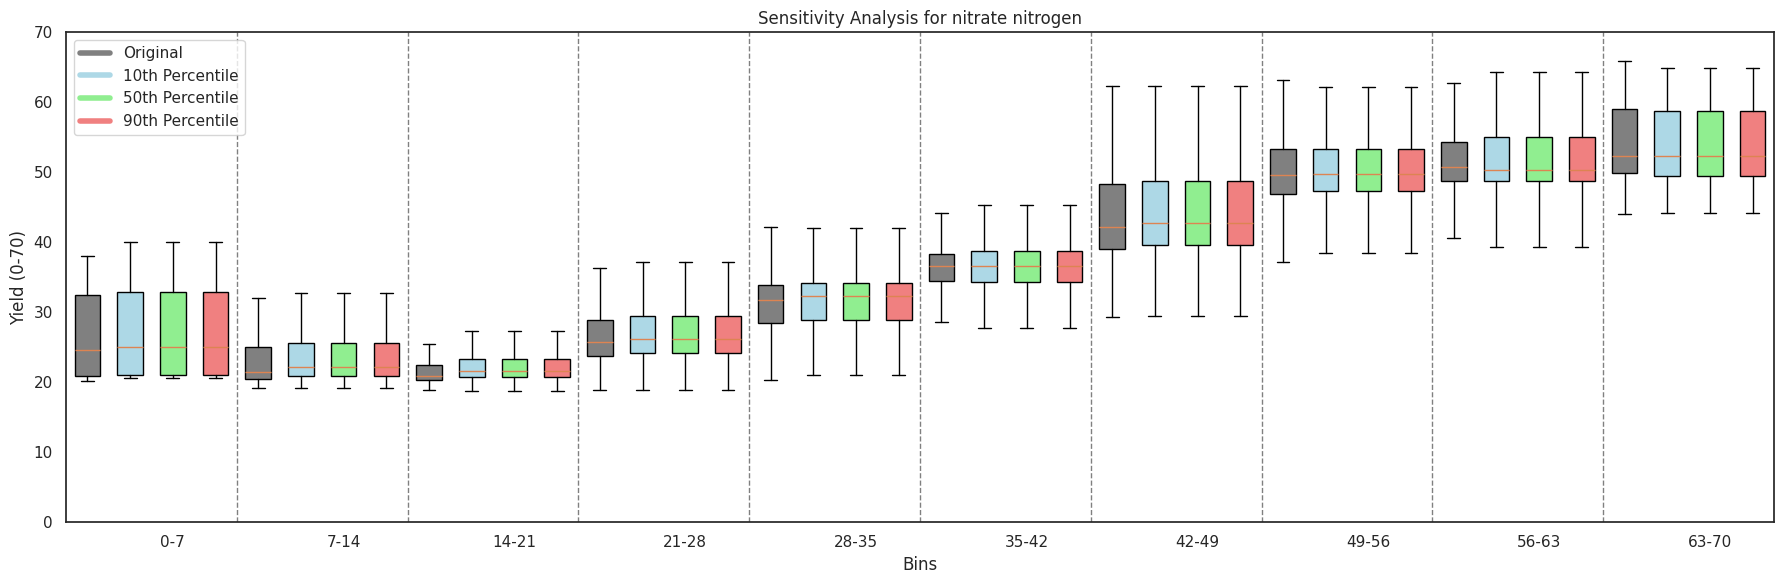

In [41]:
values = keywords_dict.get("nitrate nitrogen")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "nitrate nitrogen", 
                              values = values_list)

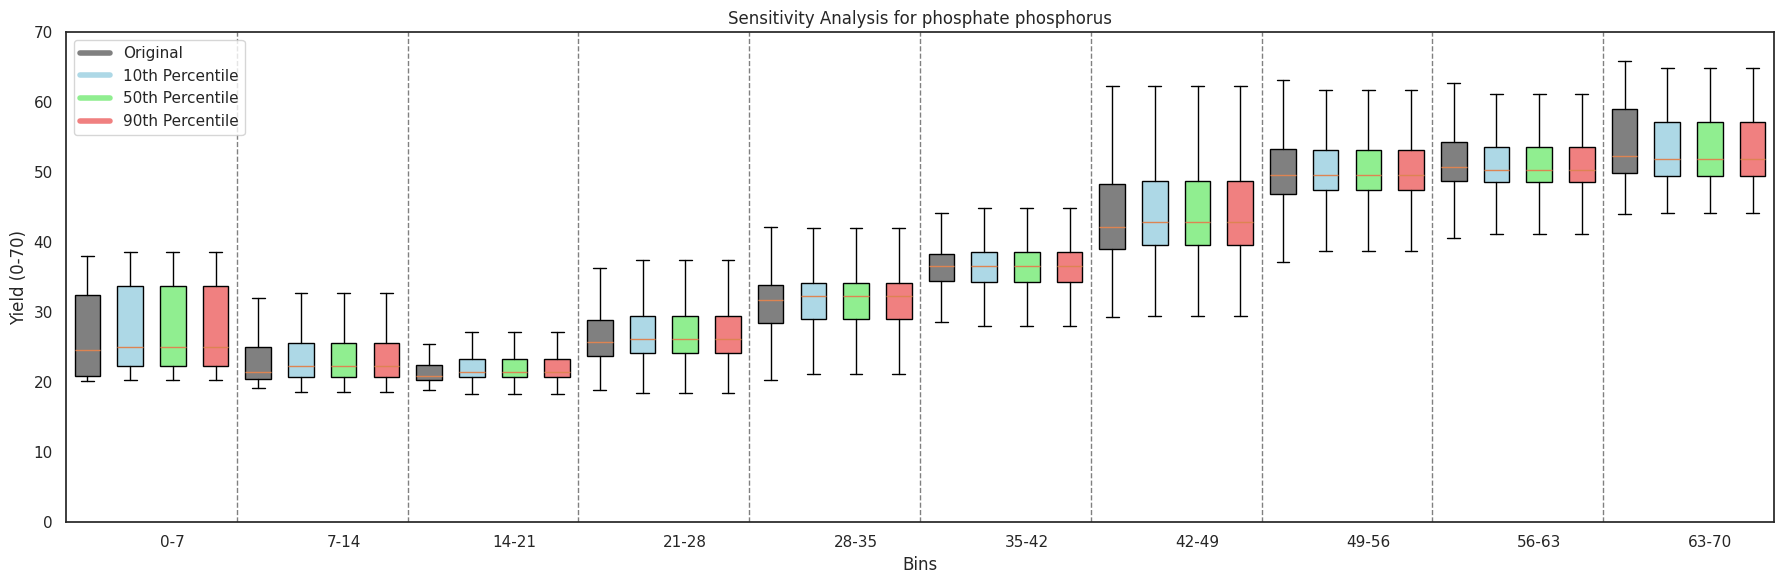

In [42]:
values = keywords_dict.get("phosphate phosphorus")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "phosphate phosphorus", 
                              values = values_list)

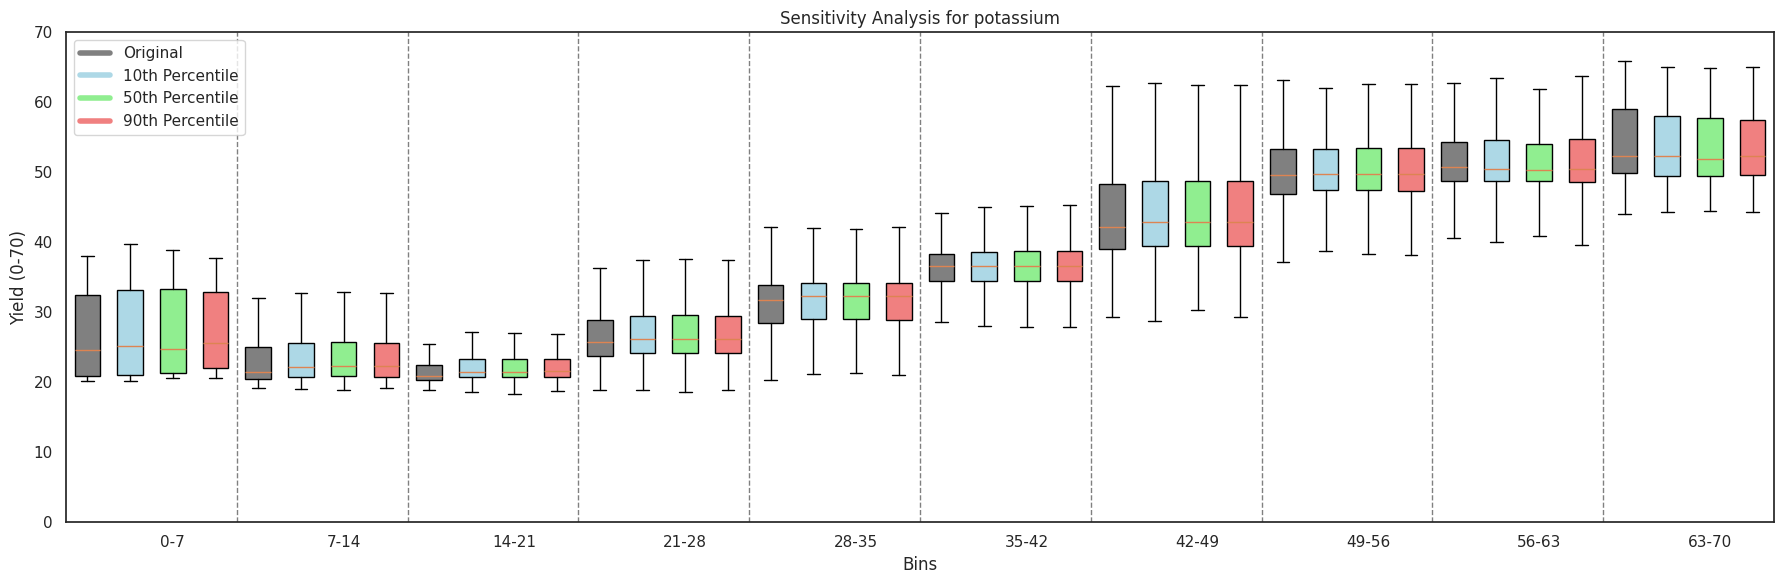

In [43]:
values = keywords_dict.get("potassium")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "potassium", 
                              values = values_list)

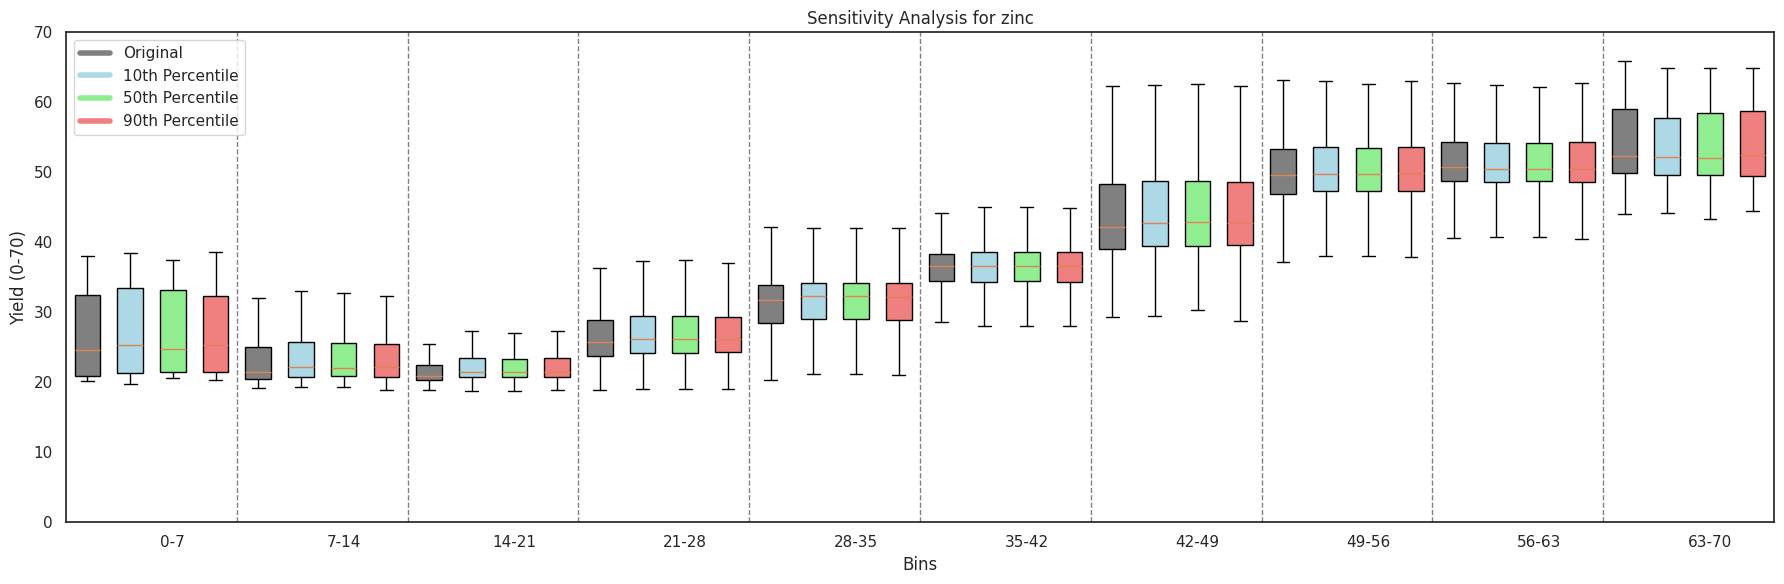

In [44]:
values = keywords_dict.get("zinc")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "zinc", 
                              values = values_list)

In [ ]:
'manganese', 'iron', 'copper', 'organic matter'

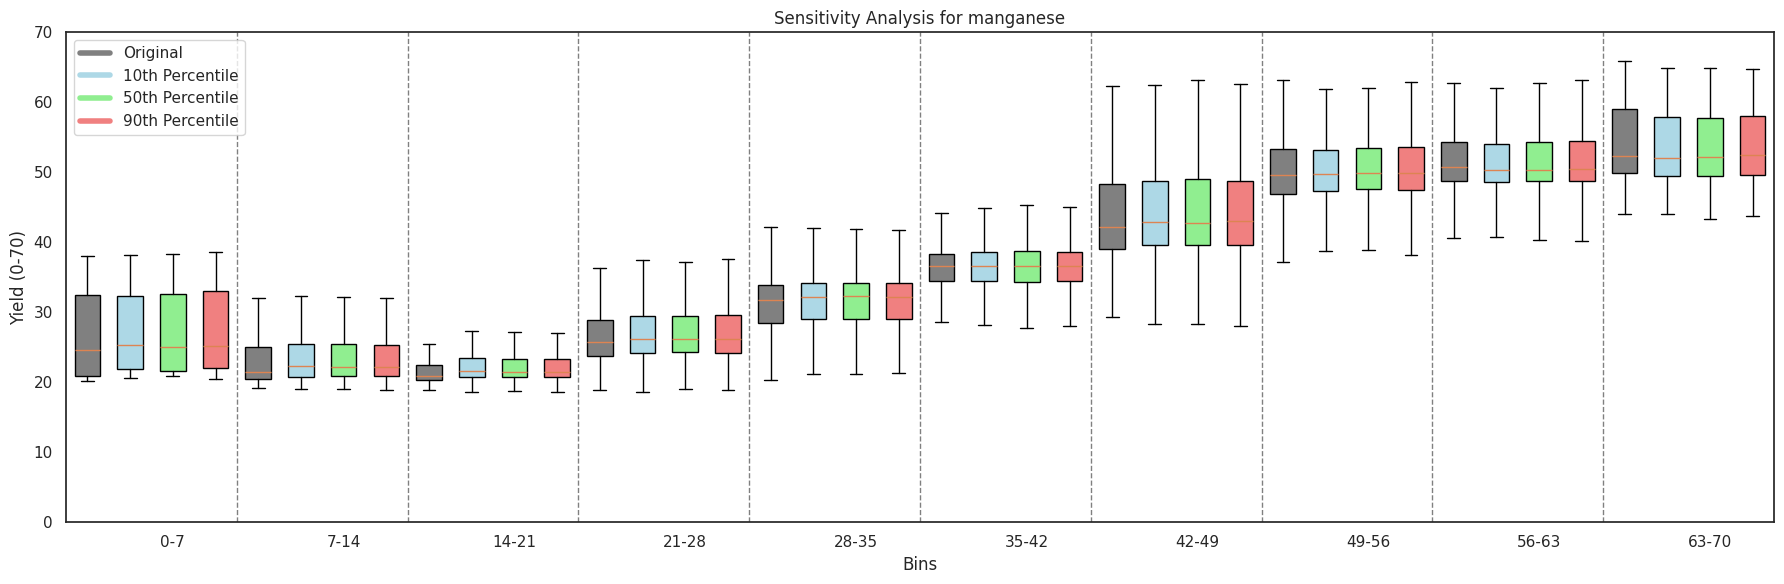

In [45]:
values = keywords_dict.get("manganese")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "manganese", 
                              values = values_list)

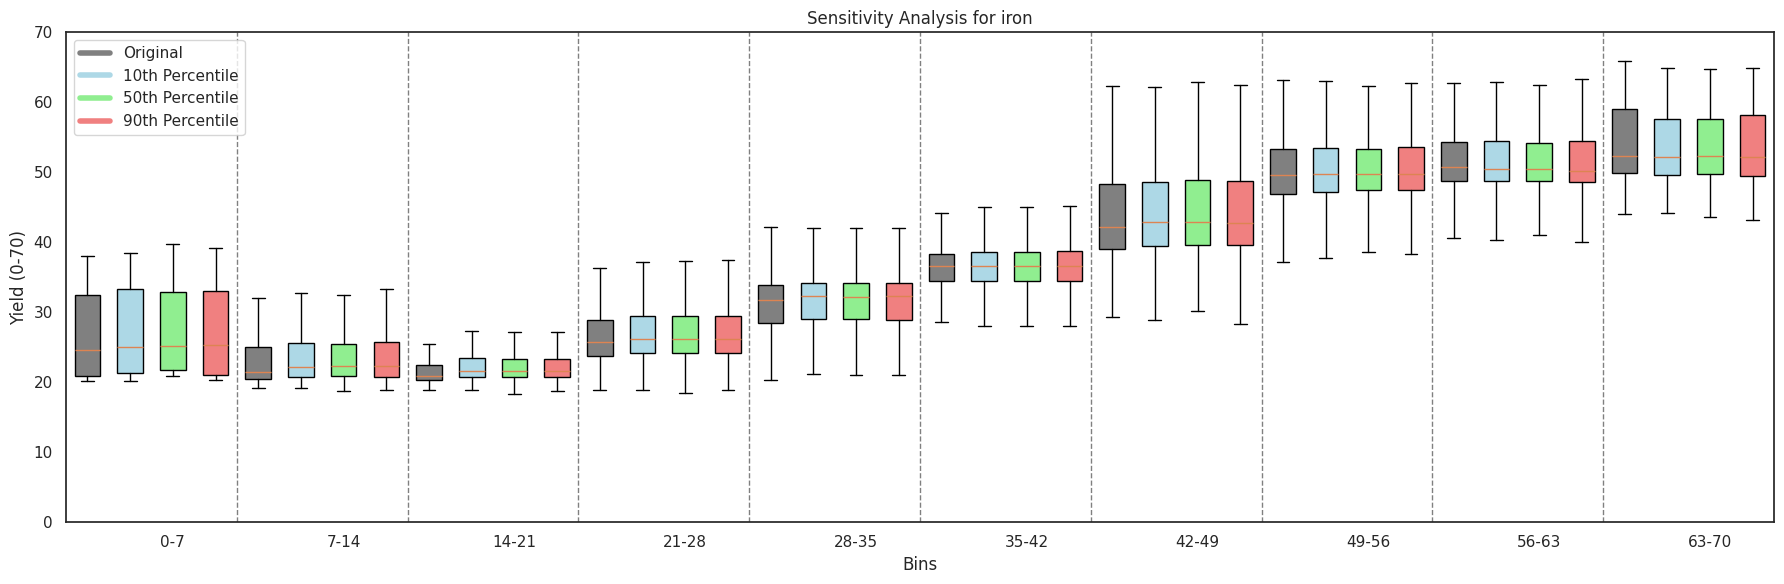

In [46]:
values = keywords_dict.get("iron")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "iron", 
                              values = values_list)

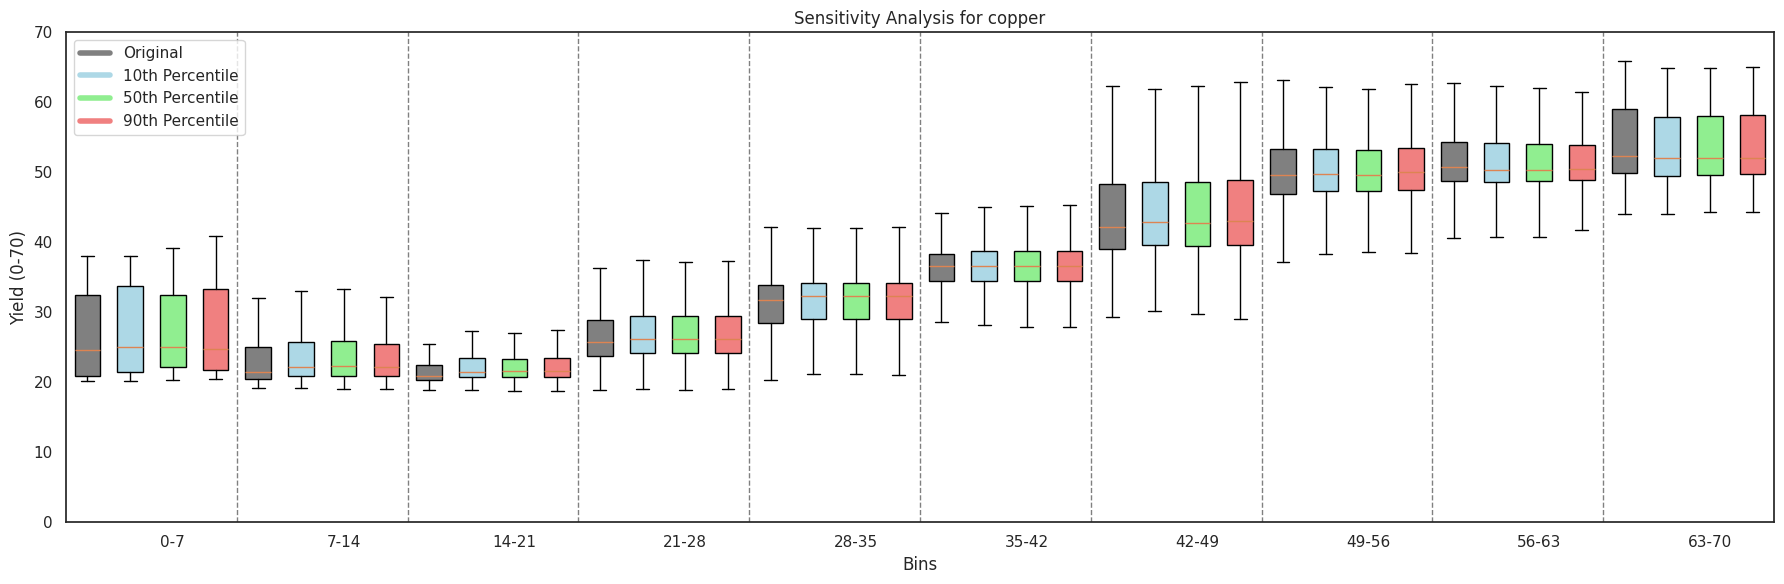

In [47]:
values = keywords_dict.get("copper")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "copper", 
                              values = values_list)

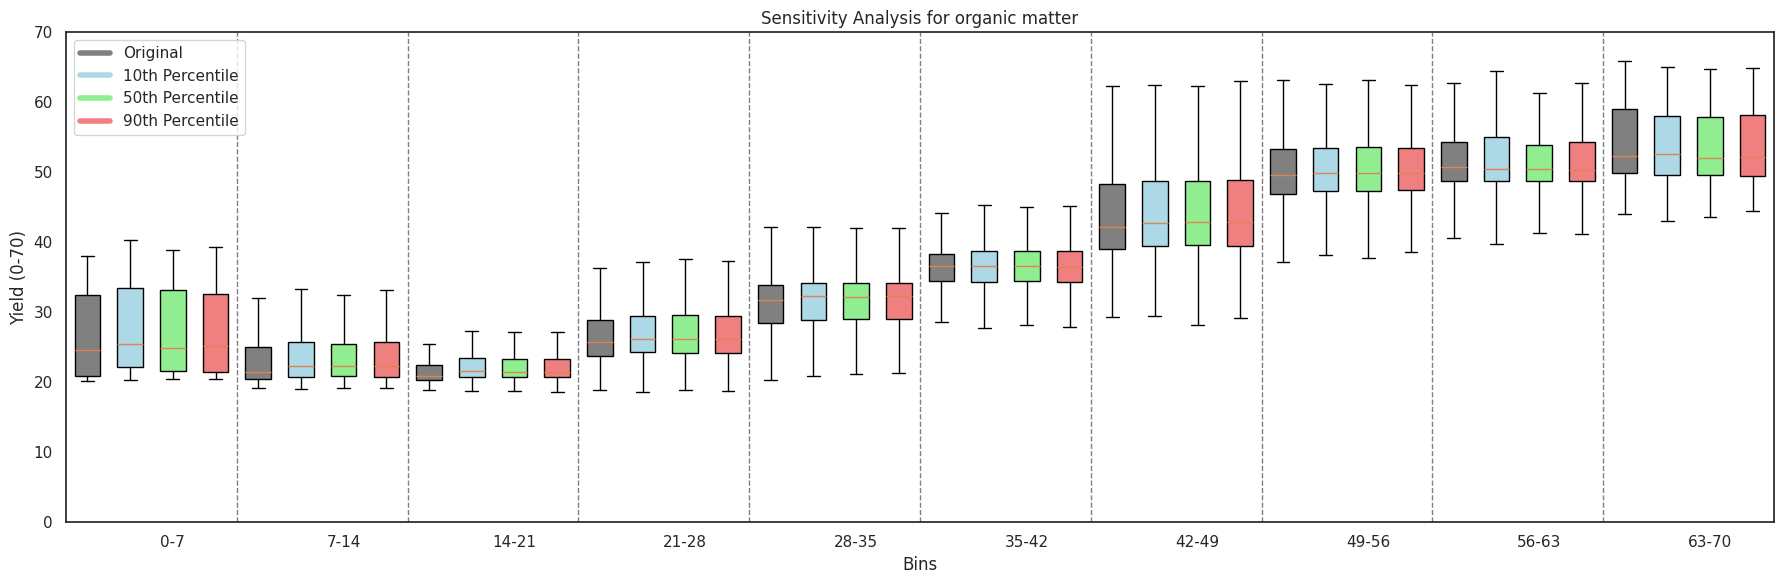

In [48]:
values = keywords_dict.get("organic matter")
values_list = list(values.values())
inf.plot_sensitivity_analysis(exp_name = E003, 
                              keyword = "organic matter", 
                              values = values_list)

In [55]:
modified_dict = dict(list(keywords_dict.items())[:2])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


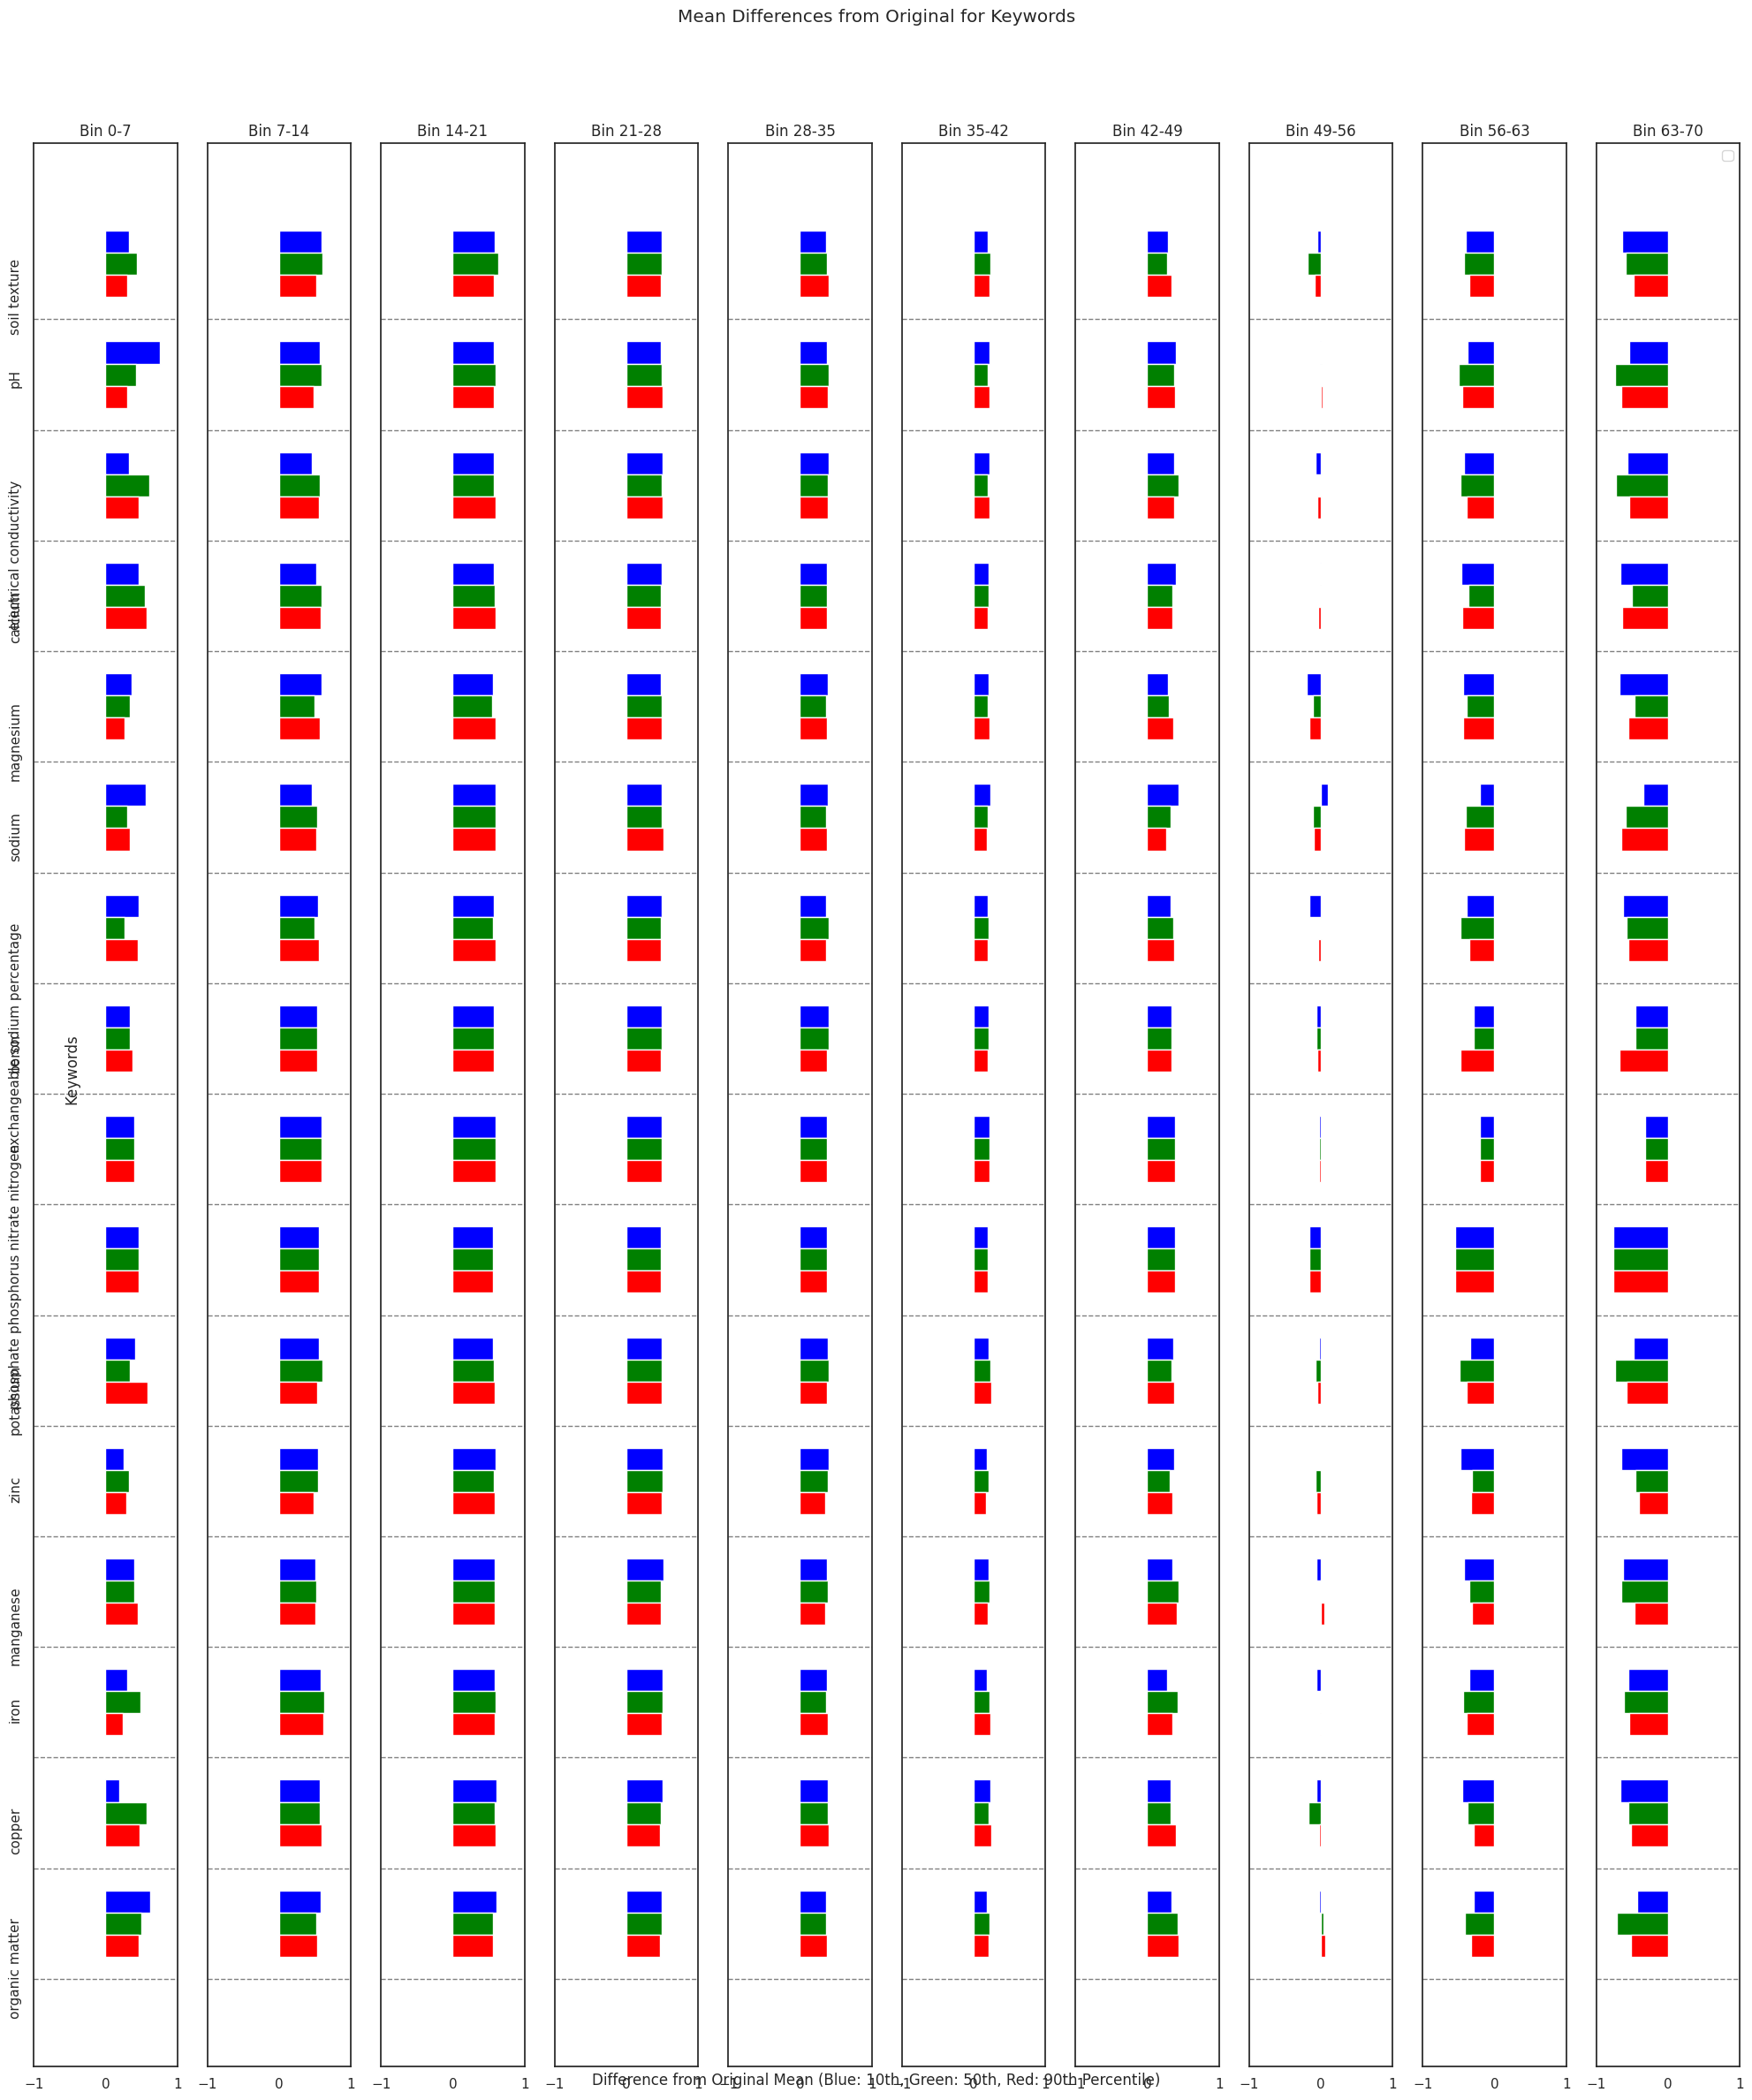

In [61]:
inf.plot_mean_difference(exp_name = E003, 
                         keywords_dict = keywords_dict)